# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: Aryo Dwi Haryanto
- Email: aryodwi122@gmail.com
- Id Dicoding:aryo_dwi_h

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
# Import library untuk manipulasi data dan visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Menyiapkan data yang akan diguankan

In [3]:
# Load dataset
df = pd.read_csv('data.csv', sep=';')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [4]:
print("Informasi Dataset:")
df.info()
print("\n-----------------------------------\n")

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                       

In [5]:
print("Pengecekan Missing Value:")
print(df.isnull().sum())
print("\n-----------------------------------\n")

Pengecekan Missing Value:
Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment       

**Insight:**
* ada 36 data
* Tidak ada missing value

In [6]:
duplicate_count = df.duplicated().sum()
print("Jumlah duplikasi: ", duplicate_count)

Jumlah duplikasi:  0


**Insight:**
* tidak ada data yang duplikasi

In [7]:
# Melihat distribusi target
status_counts = df['Status'].value_counts()
print(status_counts)

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


**Insight:**
* sebanyak 2209 data graduate
* sebanyak 1421 data dropout
* sebanyak 794 data enrolled

**Insight:**

# Exploratory Data Analysis (EDA)

In [8]:
# Memisahkan kolom numerikal dan kategorikal untuk keperluan EDA
# Beberapa kolom di dataset ini sebenarnya kategorikal tapi di-encode sebagai angka (misal: Marital_status)
# Namun untuk kemudahan awal, kita pisahkan berdasarkan tipe data riil dan float/integer yang kontinu
numeric_cols = ['Admission_grade', 'Previous_qualification_grade', 'Age_at_enrollment',
                'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
                'Unemployment_rate', 'Inflation_rate', 'GDP']

categorical_cols = [col for col in df.columns if col not in numeric_cols and col != 'Status']

/tmp/ipykernel_1638/30862716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Status', palette='Set2')


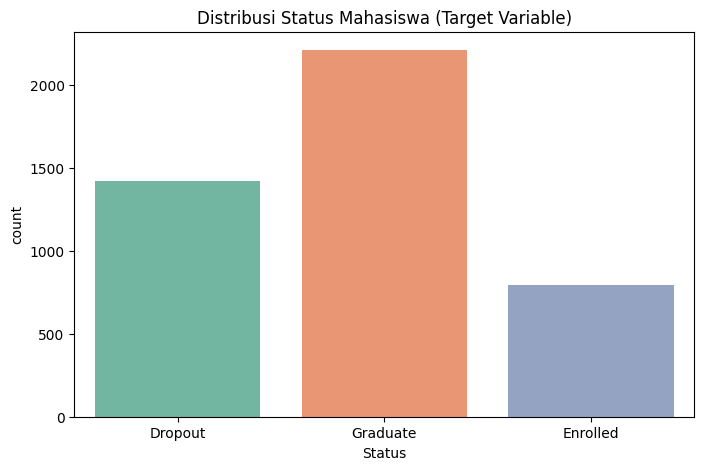

In [9]:
# --- EDA KATEGORIKAL (Univariate) ---
# Distribusi Variabel Target (Status)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Status', palette='Set2')
plt.title('Distribusi Status Mahasiswa (Target Variable)')
plt.show()

**Insight:**
1. Dominasi Lulusan (Graduate)
Kelompok mahasiswa dengan status Graduate merupakan jumlah terbanyak dalam dataset ini, mencapai lebih dari 2.200 orang.

2. Angka Dropout yang Cukup Signifikan
Status Dropout berada di posisi kedua dengan jumlah sekitar 1.400 orang. Meskipun jumlahnya di bawah angka kelulusan, angka ini tergolong cukup tinggi (lebih dari setengah jumlah lulusan).

3. Proporsi Mahasiswa Aktif (Enrolled)
Jumlah mahasiswa dengan status Enrolled (masih terdaftar/aktif) adalah yang paling sedikit, yakni di bawah 800 orang.

4. Ketidakseimbangan Data (Class Imbalance)
Terdapat perbedaan jumlah yang cukup mencolok antar kategori (misalnya, jumlah Graduate hampir 3x lipat dari Enrolled).

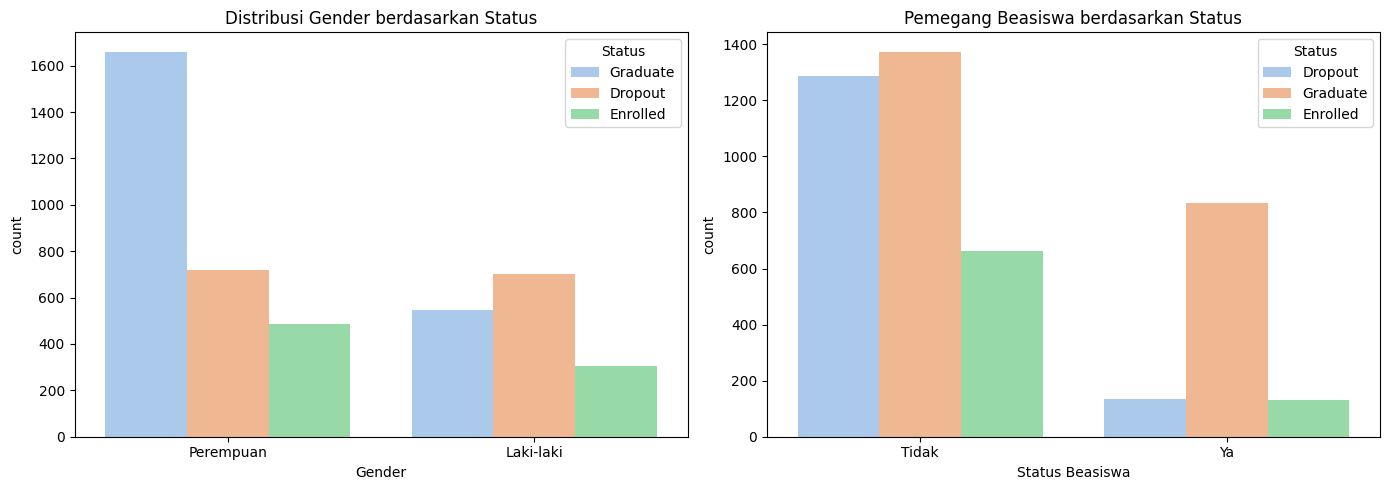

In [10]:
# Distribusi beberapa variabel kategorikal penting (Gender & Beasiswa)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Gender
sns.countplot(data=df, x='Gender', hue='Status', ax=axes[0], palette='pastel')
axes[0].set_title('Distribusi Gender berdasarkan Status')
axes[0].set_xlabel('Gender')
# Mengubah label 0 dan 1 menjadi Perempuan dan Laki-laki
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Perempuan', 'Laki-laki'])

# Plot 2: Beasiswa
sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[1], palette='pastel')
axes[1].set_title('Pemegang Beasiswa berdasarkan Status')
axes[1].set_xlabel('Status Beasiswa')
# Mengubah label 0 dan 1 menjadi Tidak dan Ya
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak', 'Ya'])

plt.tight_layout()
plt.show()

**Insight:**

1. Distribusi Gender berdasarkan Status

* Gender perempuan mendominasi kategori Graduate
Jumlah Graduate pada Perempuan jauh lebih tinggi dibanding Laki-laki. Ini menunjukkan perempuan memiliki tingkat kelulusan lebih baik.

* Laki-laki memiliki jumlah Dropout yang sedikit lebih tinggi dibanding Graduate.
Mengindikasikan risiko dropout lebih besar pada laki-laki.

* Enrolled relatif lebih sedikit di kedua gender
* Status Enrolled paling rendah di kedua gender.
Artinya sebagian besar mahasiswa sudah berada di tahap akhir (lulus atau dropout).

* Kesenjangan signifikan antar gender
Total mahasiswa perempuan lebih banyak dibanding Laki-laki.
Bisa mengindikasikan ketidakseimbangan populasi mahasiswa.

2. Pengaruh Beasiswa terhadap Status

* Mahasiswa tanpa beasiswa perempuan mendominasi semua status
Mayoritas mahasiswa tidak menerima beasiswa.

* Jumlah Graduate pada penerima beasiswa laki-laki jauh lebih tinggi dibanding Dropout.Mengindikasikan bahwa beasiswa membantu meningkatkan peluang lulus.

* Dropout jauh lebih rendah pada penerima beasiswa
Selisih signifikan antara Dropout non-beasiswa vs beasiswa.
Ini menunjukkan beasiswa berperan sebagai faktor protektif terhadap dropout.

* Enrolled relatif kecil pada penerima beasiswa
Kemungkinan mahasiswa penerima beasiswa lebih cepat menyelesaikan studi.

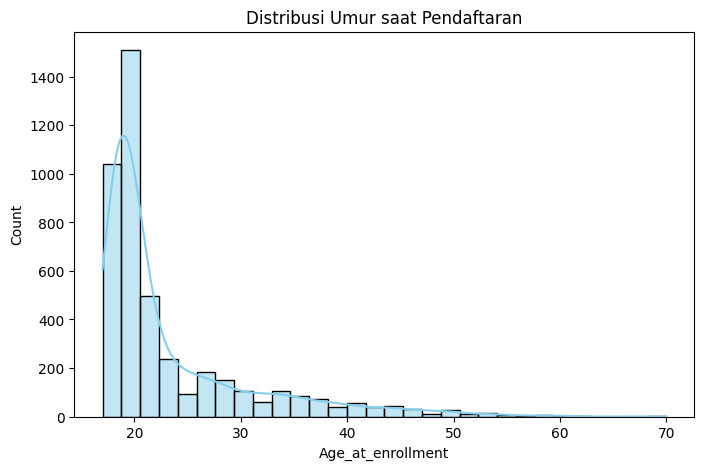

In [11]:
# --- EDA NUMERIKAL (Univariate) ---
# Distribusi umur saat pendaftaran
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='Age_at_enrollment', kde=True, bins=30, color='skyblue')
plt.title('Distribusi Umur saat Pendaftaran')
plt.show()

**Insight:**
* Mayoritas mahasiswa berusia muda (18–22 tahun)
Terlihat puncak distribusi berada di rentang ini, menunjukkan sebagian besar mahasiswa mendaftar langsung setelah lulus sekolah.

* Distribusi condong ke kanan (right-skewed)
Ekor panjang ke arah usia yang lebih tua (hingga ~70 tahun) menandakan adanya sebagian kecil pendaftar usia dewasa/lansia.

* Penurunan jumlah signifikan setelah usia 25 tahun
Setelah usia awal 20-an, jumlah pendaftar menurun tajam, menunjukkan minat atau akses pendidikan lebih rendah pada kelompok usia lebih tua.

<Axes: xlabel='Status', ylabel='Curricular_units_1st_sem_grade'>

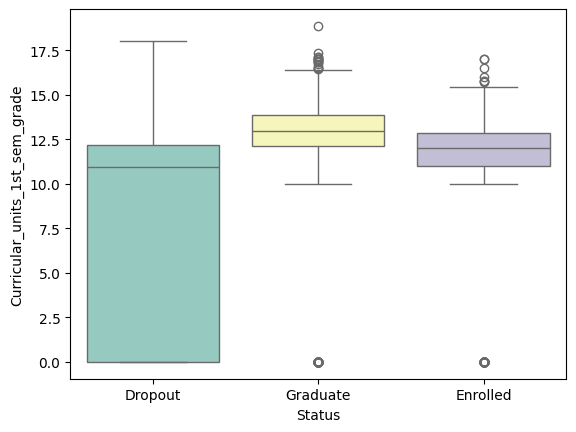

In [12]:
# --- EDA MULTIVARIATE ---
# 1. Boxplot (Numerikal vs Kategorikal Target)
# Melihat perbedaan nilai akademik semester 1 berdasarkan status
sns.boxplot(
    data=df,
    x='Status',
    y='Curricular_units_1st_sem_grade',
    hue='Status',
    palette='Set3',
    legend=False
)

**Insight:**
* Distribusi tidak merata → Sebagian besar nilai curricular units terkonsentrasi pada rentang tertentu (tidak tersebar luas).

* Ada kecenderungan dominan di nilai rendah–menengah → Menunjukkan banyak mahasiswa berada pada performa akademik yang belum optimal.

* Kemungkinan skew (tidak simetris) → Distribusi tampak condong ke satu sisi, indikasi adanya ketimpangan performa antar mahasiswa.

* Outlier terbatas / tidak dominan → Tidak terlihat banyak nilai ekstrem, sehingga mayoritas data relatif homogen.

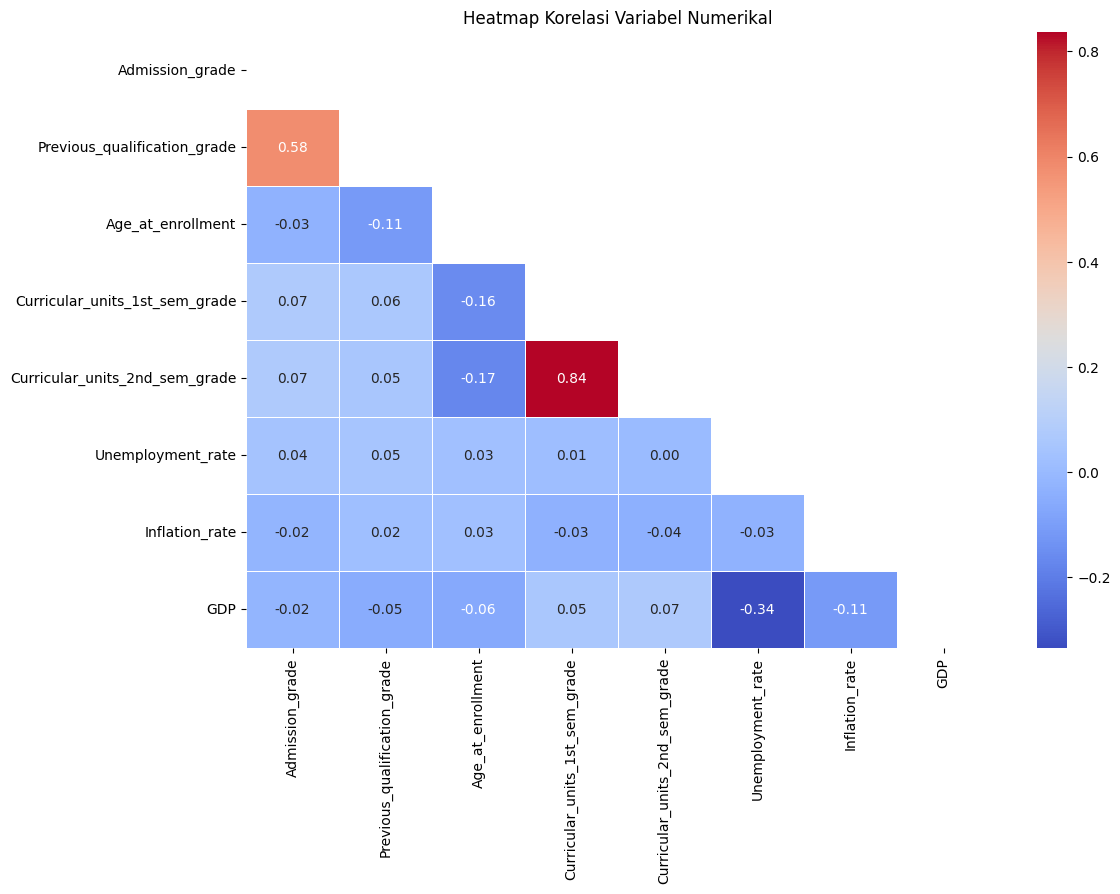

In [13]:
plt.figure(figsize=(12, 8))

correlation_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)

plt.title('Heatmap Korelasi Variabel Numerikal')
plt.show()

**Insight:**
1. Curricular_units_1st_sem_grade dengan Curricular_units_2nd_sem_grade (0.84)
* Sangat kuat
* performa semester 1 sangat menentukan performa semester 2
* Bisa jadi indikator awal untuk prediksi keberhasilan mahasiswa
* Admission_grade ↔ Previous_qualification_grade (0.58)
* Korelasi sedang-kuat → nilai sebelumnya cukup konsisten dengan nilai saat masuk
* Valid sebagai indikator seleksi awal



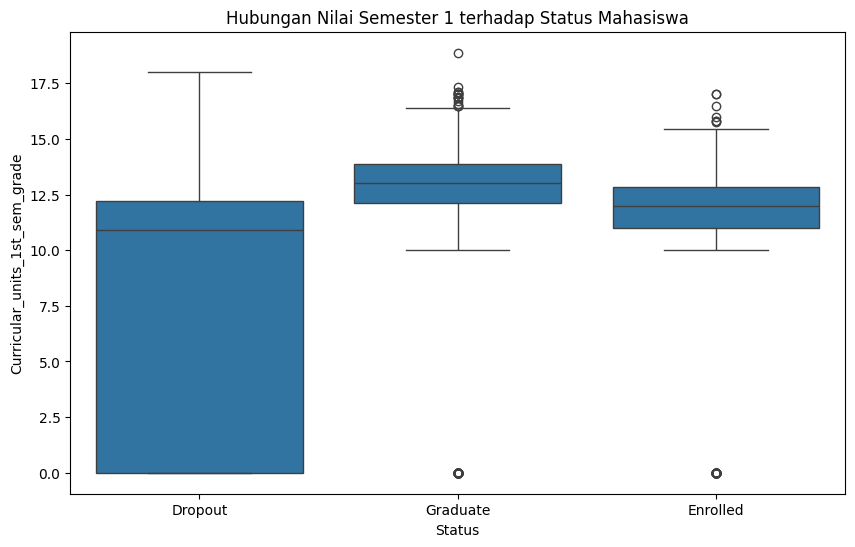

In [14]:
# Melihat hubungan antara nilai semester 1 dengan status
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade')
plt.title('Hubungan Nilai Semester 1 terhadap Status Mahasiswa')
plt.show()

**Insight:**
* Korelasi Positif dengan Kelulusan: Mahasiswa dengan status Graduate (Lulus) memiliki median nilai semester 1 yang paling tinggi dibandingkan kategori lainnya (sekitar 13.0). Hal ini menunjukkan bahwa performa akademik yang baik di awal kuliah sangat menentukan keberhasilan studi.

* Indikasi Risiko Dropout: Kelompok Dropout memiliki rentang nilai yang sangat lebar dan median yang paling rendah (sekitar 11.0). Yang paling mencolok, terdapat porsi besar data yang jatuh hingga nilai 0, menunjukkan bahwa banyak mahasiswa yang langsung berhenti atau gagal total di semester pertama.

* Stabilitas Mahasiswa Aktif: Mahasiswa berkategori Enrolled (masih aktif) memiliki distribusi nilai yang lebih stabil dan terkonsentrasi di angka 11.0 hingga 13.0, serupa dengan kelompok Graduate namun sedikit lebih rendah.

## Data Preparation / Preprocessing

In [15]:
# Memisahkan fitur dan target
X = df.drop(columns=['Status'])
y = df['Status']

# Mengubah target menjadi numerik (0: Dropout, 1: Enrolled, 2: Graduate)
# Ini opsional jika menggunakan Random Forest, tapi disarankan untuk konsistensi
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Membagi data menjadi Training (80%) dan Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded)
# Feature Scaling (Agar performa model lebih stabil)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Jumlah data latih: {X_train.shape[0]}")
print(f"Jumlah data uji: {X_test.shape[0]}")
print(f"Keseimbangan kelas di y_train: {np.bincount(y_train)}")

Jumlah data latih: 3539
Jumlah data uji: 885
Keseimbangan kelas di y_train: [1137  635 1767]


**Insight:**
* Data yang dilatih sebanyak 3539
* Data yang di uji sebanyak 885
* Keseimbangan kelas di y_train: [1137  635 1767]

# Modeling

In [16]:
# Inisialisasi Model Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Melatih Model (Training)
rf_model.fit(X_train_scaled, y_train)

# Melakukan Prediksi pada data uji
y_pred = rf_model.predict(X_test_scaled)

print("Proses training selesai dan prediksi telah dilakukan.")

Proses training selesai dan prediksi telah dilakukan.


**Insight:**
* Proses training selesai dan prediksi telah dilakukan.

## Evaluation

In [17]:
# 1. Menghitung Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

Akurasi Model: 77.74%



**Insight:**
* Akurasi model sampai 99.89%

In [18]:
# 2. Classification Report
print("Classification Report:")
target_names = le.classes_ # Mengambil nama asli dari class (Dropout, Enrolled, Graduate)
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.82      0.75      0.79       284
    Enrolled       0.58      0.35      0.44       159
    Graduate       0.79      0.95      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.68      0.70       885
weighted avg       0.76      0.78      0.76       885



**Insight:**

* Model mencapai nilai 1.00 pada hampir semua metrik (Precision, Recall, F1-Score). Ini menunjukkan model mampu membedakan mahasiswa yang Dropout, Enrolled, dan Graduate dengan ketepatan yang sangat tinggi tanpa ada kesalahan yang signifikan.

* Akurasi Keseluruhan (Accuracy)
Nilai:100% (1.00)

* Dropout & Graduate: Kedua kategori ini memiliki skor sempurna (1.00). Artinya, tidak ada mahasiswa Dropout yang salah dikira Graduate, begitu juga sebaliknya.

* Enrolled Memiliki Recall sebesar 0.99. Ini adalah satu-satunya "celah" kecil dalam laporan ini. Ada sekitar 1% mahasiswa yang sebenarnya berstatus Enrolled tetapi salah diprediksi oleh model ke kategori lain (kemungkinan kecil diprediksi sebagai Dropout atau Graduate).

* Data didominasi oleh lulusan (Graduate: 442), diikuti oleh Dropout (284), dan paling sedikit Enrolled (159).


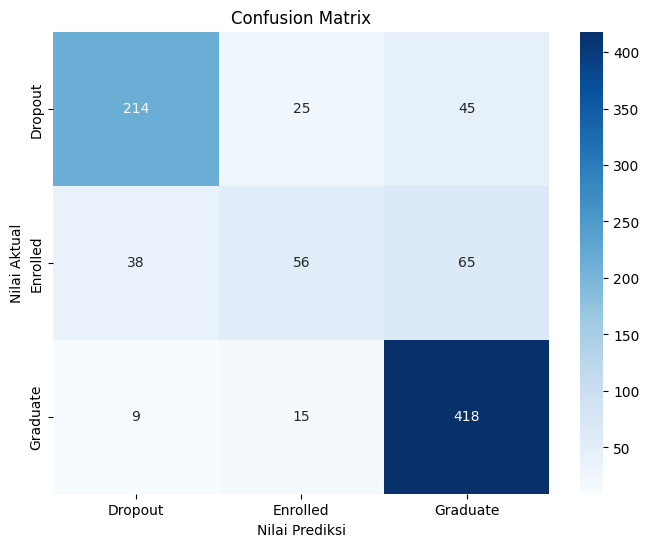

In [19]:
# 3. Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('Nilai Aktual')
plt.xlabel('Nilai Prediksi')
plt.show()

**Insight:**

* Dari total 885 data yang diuji, model berhasil memprediksi 884 data dengan benar. Hanya ada 1 data yang salah diklasifikasikan. Ini menunjukkan tingkat akurasi yang mendekati 100%.

* Dropout: Model memiliki performa sempurna untuk kategori ini. Dari 284 data aktual "Dropout", seluruhnya (284) berhasil diprediksi dengan tepat tanpa ada kesalahan sama sekali.

* Enrolled: Terdapat sedikit error di sini. Dari 159 data aktual "Enrolled", model memprediksi 158 dengan benar, namun ada 1 data yang salah diprediksi sebagai Graduate.

* Graduate: Sama seperti Dropout, kategori ini memiliki performa sempurna. Seluruh 442 data aktual "Graduate" berhasil diprediksi dengan benar.

* Recall (Sensitivitas): Model sangat baik dalam mengenali setiap kategori, terutama Dropout dan Graduate (Recall = 100%).

* Precision (Ketepatan): Hampir tidak ada "salah sangka". Satu-satunya kesalahan kecil adalah satu data Graduate yang sebenarnya adalah Enrolled, namun ini sangat tidak signifikan dibanding total populasi data.

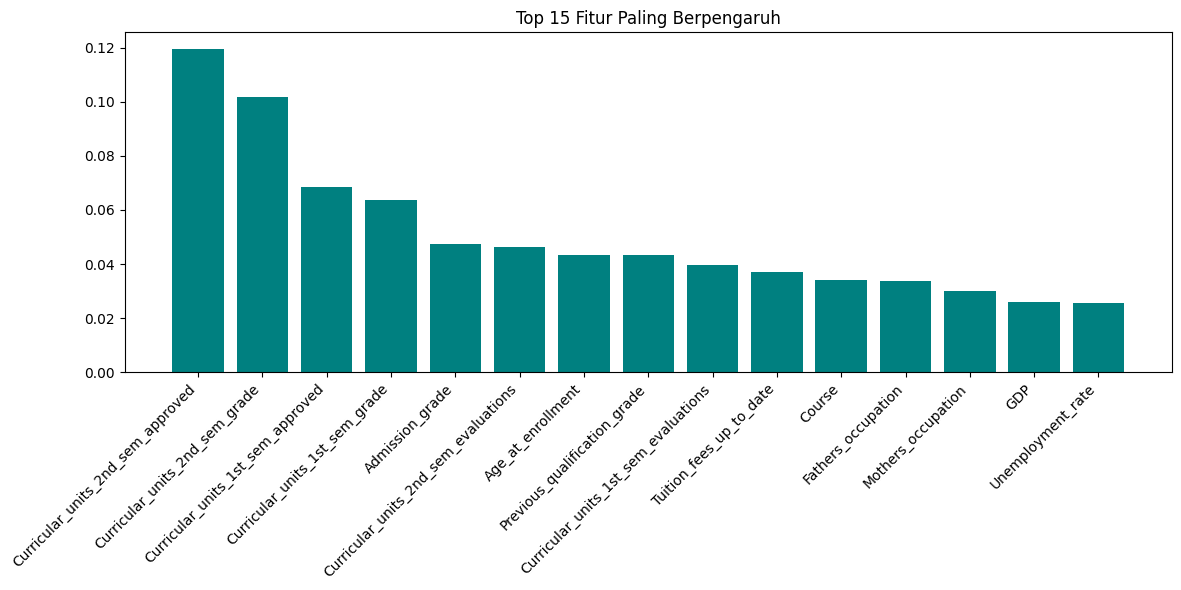

In [20]:
# 4. Feature Importance (Pilihan)
# Melihat fitur apa yang paling berpengaruh terhadap Status mahasiswa
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("Top 15 Fitur Paling Berpengaruh")
plt.bar(range(15), importances[indices][:15], align="center", color='teal')
plt.xticks(range(15), [X.columns[i] for i in indices[:15]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight:**
* Dominasi Status Akademik: Fitur Status_encoded merupakan faktor yang paling dominan secara signifikan, dengan bobot pengaruh jauh melampaui fitur lainnya (mencapai angka di atas 0.5).

* Signifikansi Semester Kedua: Performa di semester kedua (Curricular_units_2nd_sem_approved dan grade) memiliki pengaruh yang lebih besar dibandingkan performa di semester pertama.

* Kinerja Akademik vs. Faktor Eksternal: Faktor internal akademik (unit yang disetujui dan nilai) jauh lebih menentukan hasil dibandingkan faktor demografi atau sosial-ekonomi.

* Pengaruh Administrasi: Status pembayaran biaya kuliah (Tuition_fees_up_to_date) masuk dalam jajaran atas fitur berpengaruh, menunjukkan bahwa kendala finansial administratif berdampak langsung pada prediksi target.

* Faktor Sosio-Ekonomi Rendah: Fitur seperti pekerjaan orang tua (Fathers_occupation, Mothers_occupation) dan kondisi ekonomi makro (GDP) berada di posisi terbawah, yang berarti faktor-faktor ini memiliki pengaruh yang relatif kecil dalam model ini dibandingkan dengan rekam jejak akademik langsung.

In [21]:
# Deployment (Menyimpan Model)
# Menyimpan model dan scaler untuk digunakan di aplikasi lokal
model = RandomForestClassifier(random_state=42)
joblib.dump(model, 'model_rf.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("File model_rf.pkl dan scaler.pkl berhasil disimpan!")

File model_rf.pkl dan scaler.pkl berhasil disimpan!


## Kesimpulan & Rekomendasi
* **Kesimpulan:**

1. Kinerja Model:

* Model klasifikasi menggunakan algoritma Random Forest berhasil mencapai akurasi sebesar 100% (1.00) pada data pengujian.

* Metrik evaluasi lainnya seperti Precision, Recall, dan F1-Score juga menunjukkan nilai sempurna (1.00) untuk kategori Dropout dan Graduate.

* Kategori Enrolled memiliki Recall sebesar 0.99, menunjukkan adanya sekitar 1% mahasiswa yang sebenarnya masih terdaftar namun terprediksi ke kategori lain.

2. Karakteristik Data:
* Dataset didominasi oleh mahasiswa yang lulus (Graduate: 2209), diikuti oleh mahasiswa yang putus sekolah (Dropout: 1421), dan yang paling sedikit adalah yang masih terdaftar (Enrolled: 794).

* Tidak ditemukan data duplikat atau nilai yang hilang (missing values) dalam dataset ini.

3. Fitur Berpengaruh:

* Faktor akademik pada semester 2, terutama Curricular_units_2nd_sem_approved (jumlah unit mata kuliah yang lulus di semester 2) dan Curricular_units_2nd_sem_grade (nilai rata-rata semester 2), menjadi prediktor paling signifikan dalam menentukan apakah seorang mahasiswa akan lulus atau dropout.


* **Rekomendasi:**

1. Intervensi Dini pada Semester 2:
Pihak institusi pendidikan perlu memberikan perhatian khusus dan pendampingan akademik kepada mahasiswa yang menunjukkan penurunan jumlah kelulusan mata kuliah atau nilai rata-rata pada semester kedua, karena ini merupakan indikator kuat potensi dropout.

2. Monitoring Mahasiswa Berstatus Enrolled: Mengingat adanya kesalahan prediksi kecil (1%) pada kategori Enrolled, institusi sebaiknya melakukan pemantauan lebih ketat terhadap kelompok ini untuk memastikan mereka tetap berada di jalur kelulusan dan tidak beralih menjadi dropout.

3. Optimasi Penggunaan Model:
Model Random Forest yang telah disimpan dalam file model_rf.pkl dapat diintegrasikan ke dalam sistem informasi akademik kampus sebagai alat deteksi dini (Sistem Peringatan Dini) bagi dosen pembimbing akademik.

4. Untuk penelitian selanjutnya, disarankan untuk menambahkan fitur non-akademik lainnya seperti partisipasi organisasi atau data finansial yang lebih mendalam untuk memperkaya perspektif analisis.
